<a href="https://colab.research.google.com/github/sougat23bai11043-code/AI-ML-Assignments-and-Projects/blob/main/CartPole_RL_Agent_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CartPole RL Agent Training

## Machine Learning Project

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
!pip install gymnasium matplotlib numpy

In [ ]:
import gymnasium as gym
import numpy as np
import random
from collections import deque

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

In [ ]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]

action_size = env.action_space.n

print("State Size:", state_size)
print("Action Size:", action_size)

State Size: 4
Action Size: 2


In [ ]:
gamma = 0.95

epsilon = 1.0

epsilon_min = 0.01

epsilon_decay = 0.995

learning_rate = 0.001

batch_size = 32

memory = deque(maxlen=2000)

In [ ]:
model = Sequential()

model.add(Dense(24, input_dim=state_size, activation="relu"))

model.add(Dense(24, activation="relu"))

model.add(Dense(int(action_size), activation="linear"))

model.compile(
    loss="mse",
        optimizer=Adam(learning_rate=learning_rate)
        )

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def remember(state, action, reward, next_state, done):
      memory.append((state, action, reward, next_state, done))

In [ ]:
def act(state):
    global epsilon
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)

    q_values = model.predict(state, verbose=0)
    return np.argmax(q_values[0])

In [ ]:
def replay():
    global epsilon

    if len(memory) < batch_size:
        return

    minibatch = random.sample(memory, batch_size)

    for state, action, reward, next_state, done in minibatch:
        target = reward

        if not done:
            target = reward + gamma * np.amax(model.predict(next_state, verbose=0)[0])

        target_f = model.predict(state, verbose=0)

        target_f[0][action] = target

        model.fit(state, target_f, epochs=1, verbose=0)

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

In [ ]:
episodes = 5
scores = []

for episode in range(episodes):

    state, info = env.reset()
    state = state.reshape(1, state_size)

    total_reward = 0
    done = False

    while not done:

        action = act(state)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_state = next_state.reshape(1, state_size)

        remember(state, action, reward, next_state, done)

        state = next_state

        total_reward += reward

        replay()

    scores.append(total_reward)

    print("Episode", episode + 1, "Reward:", total_reward)

Episode 1 Reward: 8.0
Episode 2 Reward: 13.0
Episode 3 Reward: 22.0
Episode 4 Reward: 10.0
Episode 5 Reward: 10.0


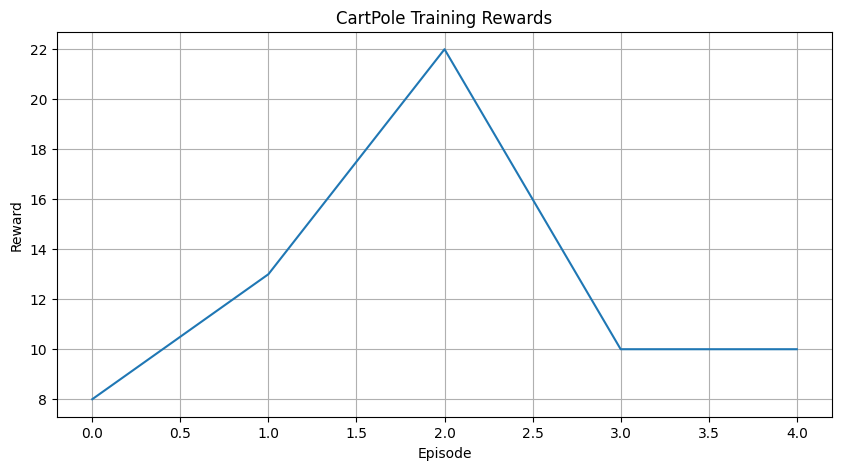

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(scores)

plt.title("CartPole Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

In [ ]:
state, info = env.reset()

state = np.reshape(state, [1, state_size])

total_reward = 0

done = False

while not done:

    action = np.argmax(model.predict(state, verbose=0)[0])
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    state = np.reshape(next_state, [1, state_size])
    total_reward += reward

print("Evaluation Reward:", total_reward)

Evaluation Reward: 8.0


In [ ]:
model.save("cartpole_dqn_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion

A Deep Q-Network (DQN) agent was implemented to solve the CartPole-v1 environment using Reinforcement Learning. The agent learned from interactions with the environment through experience replay and an epsilon-greedy policy. As training progressed, the total reward per episode generally increased, indicating improved performance. The trained model was saved for future use and demonstrates the effectiveness of deep reinforcement learning for sequential decision-making tasks.